In [3]:
!nvidia-smi

Sun Mar  8 10:24:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P0             30W /   70W |     127MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!pip install cupy-cuda12x opencv-python

In [5]:
import cupy as cp
import numpy as np
image_cpu = np.random.randint(0, 255, (512,512,3), dtype=np.uint8)
image_gpu = cp.asarray(image_cpu)
gray_gpu = cp.mean(image_gpu, axis=2)
gray_cpu = cp.asnumpy(gray_gpu)

print("Image processed successfully on GPU")
print("Image shape:", gray_cpu.shape)

Image processed successfully on GPU
Image shape: (512, 512)


In [6]:
from sklearn.datasets import fetch_openml

print("Downloading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1)

images = mnist.data
labels = mnist.target

print("Total images in dataset:", images.shape[0])

Total images in dataset: 70000


In [7]:
import os
import cv2
import numpy as np

os.makedirs("mnist_images", exist_ok=True)

for i in range(500):
    img = images.iloc[i].values.reshape(28,28)
    img = img.astype(np.uint8)

    cv2.imwrite(f"mnist_images/img_{i}.png", img)

print("500 MNIST images saved")

500 MNIST images saved


In [8]:
import cupy as cp
import cv2
import os

os.makedirs("output", exist_ok=True)

files = os.listdir("mnist_images")

print("Processing images:", len(files))

for file in files:

    path = os.path.join("mnist_images", file)
    img = cv2.imread(path, 0)
    gpu_img = cp.asarray(img)
    processed_gpu = cp.sqrt(gpu_img.astype(cp.float32))
    result = cp.asnumpy(processed_gpu)
    cv2.imwrite("output/" + file, result)

print("GPU image processing completed!")

Processing images: 500
GPU image processing completed!


In [9]:
import cupy as cp
import numpy as np
import time


image_cpu = np.random.randint(0,255,(1024,1024,3),dtype=np.uint8)
start_cpu = time.time()

gray_cpu = np.mean(image_cpu,axis=2)
cpu_time = time.time() - start_cpu
start_gpu = time.time()
image_gpu = cp.asarray(image_cpu)
gray_gpu = cp.mean(image_gpu,axis=2)
gray_gpu_cpu = cp.asnumpy(gray_gpu)
gpu_time = time.time() - start_gpu


print("CPU Time:", cpu_time)
print("GPU Time:", gpu_time)
print("Speedup GPU vs CPU:", cpu_time/gpu_time)

CPU Time: 0.0274350643157959
GPU Time: 0.0040264129638671875
Speedup GPU vs CPU: 6.813773093320701


In [10]:
import cupy as cp
import cv2
import os
import time

os.makedirs("output", exist_ok=True)

files = os.listdir("mnist_images")

start = time.time()

for file in files:

    path = os.path.join("mnist_images", file)
    img = cv2.imread(path,0)
    gpu_img = cp.asarray(img)
    processed_gpu = cp.sqrt(gpu_img.astype(cp.float32))
    result = cp.asnumpy(processed_gpu)
    cv2.imwrite("output/"+file,result)
total_gpu_time = time.time() - start

print("Processed",len(files),"images on GPU")
print("Total GPU Time:",total_gpu_time,"seconds")

Processed 500 images on GPU
Total GPU Time: 0.21869349479675293 seconds


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

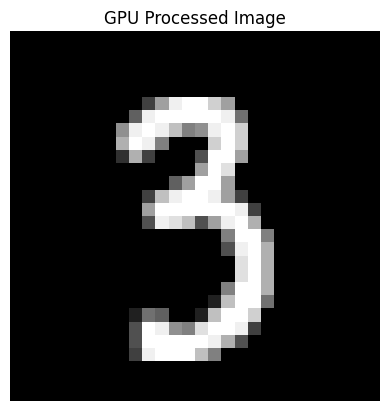

In [19]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("output/img_98.png",0)

plt.imshow(img,cmap="gray")
plt.title("GPU Processed Image")
plt.axis("off")